# 第四章 逻辑回归模型 

# 1.案例实战 - 银行客户违约预警模型

1.案例实战 - 基于逻辑回归算法的客户违约预测模型

（1）读取代码所在文件夹中的“客户信息及违约表现.xlsx”；

（2）提取特征变量和目标变量；

（3）划分训练集和测试集数据（其中test_size=0.2）；

（4）建立逻辑回归模型；

（5）预测数据结果（预测测试集结果），并通过DataFrame进行展示前5行数据；

（6）预测概率，并通过DataFrame进行展示前5行数据；

（7）查看逻辑回归系数；

In [1]:
# 1.读取数据（客户信息及违约表现.xlsx）
import pandas as pd
df = pd.read_excel('客户信息及违约表现.xlsx')

In [2]:
# 2.划分特征变量和目标变量
X = df.drop(columns='是否违约')
y = df['是否违约']

In [3]:
# 3.划分训练集和测试集
from sklearn.model_selection import train_test_split
# 设置random_state使得每次划分的数据一样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
# 显示训练集X_train的前5行
print(X_train.head())
# 显示训练集y_train的前5行
print(y_train.head())
# 显示测试集X_test的前5行
print(X_test.head())
# 显示测试集y_test的前5行
print(y_test.head())

          收入  年龄  性别  历史授信额度  历史违约次数
512   233333  33   0    7000       0
685  2037360  34   1   27000       2
997   333333  44   1   10000       0
927  1210238  37   1  195500       2
376   291000  46   0    3000       1
512    0
685    0
997    0
927    0
376    1
Name: 是否违约, dtype: int64
         收入  年龄  性别  历史授信额度  历史违约次数
131  476000  29   0       0       1
203  800000  43   1   24000       1
50   333333  46   1   10000       0
585  463000  41   0    1000       0
138  633333  34   0   19000       1
131    1
203    1
50     1
585    0
138    1
Name: 是否违约, dtype: int64


In [4]:
# 4.模型搭建
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
# 5.模型使用1 - 预测数据结果
y_pred = model.predict(X_test)
# 打印预测内容的前100个看看
print(y_pred[:100])

[1 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1
 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 0]


In [6]:
# 将预测值和实际值放到一个DataFrame里进行查看比对
res = pd.DataFrame({'实际值': y_test, '预测值': y_pred})
# 可以看到此时前5个预测准确度为80%
print(res.head())

     实际值  预测值
131    1    1
203    1    1
50     1    0
585    0    0
138    1    1


In [7]:
# 查看全部的预测准确度
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred, y_test))

0.745


In [8]:
# 另外一种查看模型预测准确度的方法
print(model.score(X_test, y_test))

0.745


In [9]:
# 6.模型使用2 - 预测概率，并显示5行
y_pred_prob = model.predict_proba(X_test)
print(y_pred_prob[:5])

[[0.37482186 0.62517814]
 [0.49585127 0.50414873]
 [0.80069978 0.19930022]
 [0.76357379 0.23642621]
 [0.42177401 0.57822599]]


In [10]:
# 另一种查看概率的方式，并显示5行
df_prob = pd.DataFrame(y_pred_prob, columns=['0_概率', '1_概率'])
print(df_prob.head())

       0_概率      1_概率
0  0.374822  0.625178
1  0.495851  0.504149
2  0.800700  0.199300
3  0.763574  0.236426
4  0.421774  0.578226


In [11]:
# 只查看流失的概率（也即y=1概率，即上面二维数组的第二列）
print(y_pred_prob[:, 1][:5])

[0.62517814 0.50414873 0.19930022 0.23642621 0.57822599]


In [12]:
# 7.查看各个特征变量的系数：系数和截距项
print(model.coef_)
print(model.intercept_)

[[ 7.89531473e-08 -2.92706061e-02 -3.22654739e-02 -3.27155585e-06
   1.32841418e+00]]
[-0.00556253]


In [13]:
# 通过公式获取流失概率，这里演示前5条测试集数据的预测流失的概率
import numpy as np
logit = np.dot(X_test.head(), model.coef_.T) + model.intercept_
print(1 / (1 + np.exp(-logit)))

[[0.62517814]
 [0.50414873]
 [0.19930022]
 [0.23642621]
 [0.57822599]]


#  4.案例实战 - 评估基于逻辑回归算法的客户违约预测模型**

（1）绘制KS曲线

（2）计算KS值

补充知识点：混淆矩阵的Python实现

In [14]:
# 导入相关模块
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [15]:
# 1.计算ROC曲线需要的假警报率（fpr）、命中率（tpr）及阈值（thres）
fpr, tpr, thres = roc_curve(y_test, y_pred_prob[:, 1])

In [16]:
# 2.# 创建一个空DataFrame ，查看前5条假警报率（fpr）、命中率（tpr）及阈值（thres）
df_roc = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thres': thres})
print(df_roc.head())

        fpr       tpr     thres
0  0.000000  0.000000       inf
1  0.000000  0.011494  0.996857
2  0.000000  0.229885  0.828415
3  0.017699  0.229885  0.818551
4  0.017699  0.252874  0.818213


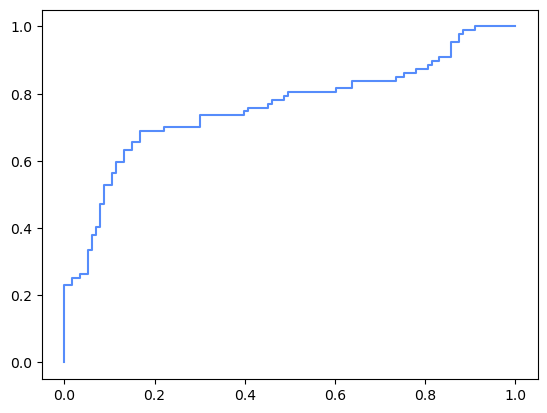

In [17]:
# 3.绘制ROC曲线
plt.plot(fpr, tpr)
plt.show()

In [18]:
# 4.求出模型的AUC值
print(roc_auc_score(y_test, y_pred_prob[:, 1]))

0.7590275658630862


# 补充知识点：KS曲线绘制

In [19]:
#1.计算ROC曲线需要的假警报率（fpr）、命中率（tpr）及阈值（thres）
fpr, tpr, thres = roc_curve(y_test, y_pred_prob[:, 1])

In [20]:
# 创建一个空DataFrame ，查看前5条的假警报率（fpr）、命中率（tpr）及阈值（thres）a = pd.DataFrame()  
df_ks = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thres': thres})

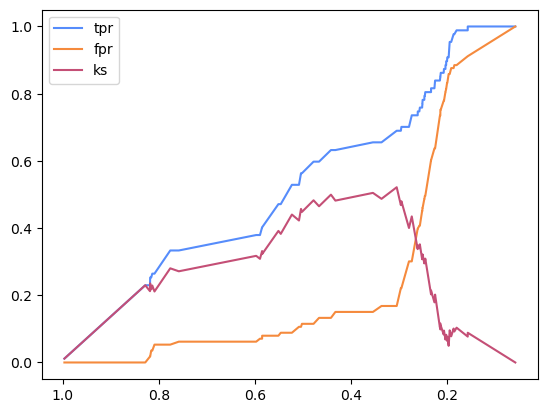

In [21]:
# 3.绘制KS曲线
plt.plot(thres, tpr, label='tpr')
plt.plot(thres, fpr, label='fpr')
plt.plot(thres, tpr - fpr, label='ks')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

In [22]:
#快速求出KS值
print(max(tpr - fpr))

0.5215135794934391


In [23]:
# KS值对应的阈值，并显示前5条
df_ks['ks'] = df_ks['tpr'] - df_ks['fpr']
print(df_ks.sort_values(by='ks', ascending=False).head())

         fpr       tpr     thres        ks
26  0.168142  0.689655  0.304700  0.521514
24  0.150442  0.655172  0.354193  0.504730
22  0.132743  0.632184  0.441666  0.499441
25  0.168142  0.655172  0.336335  0.487031
20  0.115044  0.597701  0.477881  0.482657


In [24]:
# 另外一种获取KS值的方式
from scipy.stats import ks_2samp
print(ks_2samp(y_pred_prob[:, 1][y_test == 0], y_pred_prob[:, 1][y_test == 1]).statistic)

0.5215135794934391


In [25]:
# 获取KS值对应的阈值等信息
best_ks = df_ks.loc[(df_ks['tpr'] - df_ks['fpr']).idxmax()]
print(best_ks)

fpr      0.168142
tpr      0.689655
thres    0.304700
ks       0.521514
Name: 26, dtype: float64
